# 🌤️ **Acquisition, Decoding, and Analysis of Surface Weather Reports (METAR)**
---

### **Context**
In this notebook, we execute a surface **weather data analysis workflow** that reflects **operational meteorology** practices: acquiring raw coded observations, decoding them into a structured numerical format, and visualizing the resulting physical variables on station plot models, either individually or on a map to perform a synoptic overview analysis. Specifically, we focus on METAR (Meteorological Aerodrome Report), which is the international standard format for reporting hourly and sub-hourly surface weather observations globally.

### **Learning Goals:**
- 🎯 **Goal 1 | Data Acquisition**: Fetch live or archived METARs
- 🎯 **Goal 2  | Data Processing**: Transform the raw alphanumeric strings into structured surface weather observations, perform unit conversions, and apply basic Quality Control (QC) checks
- 🎯 **Goal 3 | Station Visualization**: Visualize individual station data using the standard station plot model 
- 🎯 **Goal 4 | Synoptic Overview**: Map multiple station plots to visualize large-scale prevailing weather conditions

**Run the notebook via the Binder platform:**

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/one-weather-lab/weather-analysis-and-forecasting/HEAD)

---

## ⚙️ Setup

First, let's import the necessary libraries and configure our environment.

In [1]:
# Import required libraries
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# Core data science stack
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

# Visualization
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# MetPy for station plots
from metpy.plots import StationPlot, sky_cover

# Add local utils to path
sys.path.insert(0, str(Path('../utils').resolve()))

# Import our custom utilities
from iem_raw import fetch_iem_raw
from noaa_realtime import fetch_noaa_realtime
from metar_helpers import (
    decode_metar_row,
    check_dewpoint_consistency,
    check_rh_range,
    check_wind_temporal_spike,
)
from plot_helpers import (
    fetch_station_coords,
    build_network_plot_df,
    plot_greece_metar_network,
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set up nice plotting defaults
plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('[OK] All libraries loaded successfully!')


[OK] All libraries loaded successfully!


---

# Section 1: Data Acquisition

## 1.1 Understanding Surface Weather Data & METAR

### The Global Observing System (GOS)

Surface weather observations are a significant component of the [Global Observing System (GOS)](https://www.google.com/url?sa=E&q=https%3A%2F%2Fwmo.int%2Factivities%2Fglobal-observing-system-gos%2Fglobal-observing-system-gos).Data is collected from multiple networks of ground-based stations across the globe that operate in manual (staffed by human observers), fully automatic (Automatic Weather Stations - AWS), or hybrid configutions. Regardless of the type, these stations measure critical **atmospheric variables**, including air temperature and dew point, which are used to generate standardized METAR reports.

### The METAR Code

**METAR** is the international standard (World Meteorological Organization (WMO) code form FM-15) for reporting hourly and sub-hourly surface weather observations. It is a compact, alphanumeric string used worldwide in:
- **Aviation**: By pilots and flight planners for takeoff/landing safety.
- **Meteorology**:  Plotted on surface maps for synoptic analysis; ingested into Numerical Weather Prediction (NWP) models (data assimilation); used for NWP model validation and other operational and research applications.  

### Example METAR String

Below is a real-world example from Ioannina, Greece

```
METAR LGIO 171920Z 30003KT 9999 -RA BKN020 SCT060 05/04 Q0997=

```

Let's decode this:

| Element | Meaning |
|---------|--------|
| `METAR` | Report format identifier |
| `LGIO` | ICAO<sup>(1)</sup> station code (Ioannina, Greece) |
| `171920Z` | Day 17 of the month, time 19:20 UTC (Zulu)<sup>(2)</sup> |
| `30003KT` | Wind from 300° at 3 knots |
| `9999` | Visibility ≥10 km |
| `-RA` | Light rain |
| `BKN020` | Broken clouds at 2000 ft |
| `SCT060` | Scattered clouds at 6000 ft |
| `05/04` | Temperature 5°C / Dewpoint 4°C |
| `Q0997` | Sea-level pressure 997 hPa |

<small>
(1) ICAO = International Civil Aviation Organization<br>
(2) This observation was obtained on 17 February 2026
</small>

### Data Access: Where do we get the data?

Meteorological reports can be retrieved from various providers depending on the requirements for real-time operational monitoring or retrospective analysis. Key sources include:

#### 1. [NOAA NWS](https://tgftp.nws.noaa.gov/data/observations/metar/stations/)
The FTP (File Transfer Protocol) service provided by the National Weather Service (NWS) of the National Oceanic and Atmospheric Administration (NOAA) maintains the latest METAR reports for the majority of international airports. It offers direct access to the most recent observations (within the last 1–2 hours) from the [Global Telecommunication System](https://wmo.int/site/knowledge-hub/programmes-and-initiatives/global-telecommunication-system-gts), allowing for **operational real-time data ingestion**.
#### 2. [Ogimet](https://www.ogimet.com/umetars.phtml.en)
A specialized web interface that aggregates and displays real-time and archived METAR, facilitating **quick human inspection and verification**. It also provides access to other weather products, including SYNOP (surface synoptic observations).
#### 3. [Iowa Environmental Mesonet (IEM)](https://mesonet.agron.iastate.edu/request/download.phtml)
Beyond real-time weather reports, the IEM maintains an extensive global archive of METAR data, enabling **long-term climatological analyses**. Additionally, the service offers direct downloads of decoded observations, significantly simplifying the data processing steps.

## 1.2 Select Data Mode and Stations

**Instructions:**
1. **Choose your Data Mode** in the cell below (`'realtime'` for the latest observations or `'retrospective'` for historical data)
2. **Set your target date** (only applicable for `'retrospective'` mode)
3. **Review the list of surface weather stations** and **comment out** (add `#` at the start of the line) any you wish to exclude

In [2]:
# =============================================================================
# CONFIGURATION SECTION
# =============================================================================

# ---------------------------------------------------------------------------
# DATA MODE
# ---------------------------------------------------------------------------
# 'realtime'     -> fetch the LATEST available observation for each station
#                   directly from the NOAA NWS FTP server.
#
# 'retrospective' -> fetch a full day of historical records from the IEM
#                   METAR archive.
DATA_MODE = 'realtime'   # <-- CHANGE TO 'retrospective' FOR HISTORICAL DATA

# ---------------------------------------------------------------------------
# RETROSPECTIVE SETTINGS (used only when DATA_MODE = 'retrospective')
# ---------------------------------------------------------------------------
TARGET_DATE = '2021-08-03'  # <-- MODIFY THIS (YYYY-MM-DD)

# ---------------------------------------------------------------------------
# HNMS (Hellenic National Meteorological Service) AVIATION WEATHER STATIONS (LG** Airports)
# Comment out any station you DON'T want to include
# ---------------------------------------------------------------------------
GREEK_STATIONS = [
    'LGAD',  # Andravida Air Base
    'LGAL',  # Alexandroupoli Democritus Airport
    'LGAV',  # Athens Eleftherios Venizelos International Airport
    'LGBL',  # Nea Anchialos National Airport
    'LGEL',  # Elefsis Air Base
    'LGHI',  # Chios Island National Airport
    'LGIO',  # Ioannina King Pyrrhus National Airport  <- focus station
    'LGIR',  # Heraklion International Nikos Kazantzakis Airport
    'LGKC',  # Kithira Airport
    'LGKF',  # Kefallinia Airport
    'LGKL',  # Kalamata Airport
    'LGKO',  # Kos International Airport (Ippokratis)
    'LGKP',  # Karpathos Airport
    'LGKR',  # Corfu Ioannis Kapodistrias International Airport
    'LGKV',  # Kavala Alexander the Great International Airport
    'LGKZ',  # Kozani National Airport Filippos
    'LGLM',  # Limnos Airport
    'LGLR',  # Larissa Air Base
    'LGMK',  # Mykonos Island National Airport
    'LGMT',  # Mytilene International Airport
    'LGNX',  # Naxos Island National Airport
    'LGPA',  # Paros National Airport
    'LGPZ',  # Aktion National Airport (Preveza)
    'LGRP',  # Rhodes International Airport (Diagoras)
    'LGRX',  # Patras Araxos Agamemnon Airport
    'LGSA',  # Chania International Airport (Souda)
    'LGSK',  # Skiathos Island National Airport
    'LGSM',  # Samos Airport
    'LGSO',  # Syros Airport
    'LGSR',  # Santorini International Airport
    'LGSY',  # Skiros Airport
    'LGTG',  # Tanagra Air Base
    'LGTS',  # Thessaloniki Macedonia International Airport
    'LGZA',  # Zakynthos International Airport Dionysios Solomos
]

# =============================================================================

print(f"[DATA MODE] {DATA_MODE.upper()}",
      f"| Date: {TARGET_DATE}" if DATA_MODE == 'retrospective' else "")
print(f"[STATIONS ] {len(GREEK_STATIONS)} stations selected: {', '.join(GREEK_STATIONS)}")


[DATA MODE] REALTIME 
[STATIONS ] 34 stations selected: LGAD, LGAL, LGAV, LGBL, LGEL, LGHI, LGIO, LGIR, LGKC, LGKF, LGKL, LGKO, LGKP, LGKR, LGKV, LGKZ, LGLM, LGLR, LGMK, LGMT, LGNX, LGPA, LGPZ, LGRP, LGRX, LGSA, LGSK, LGSM, LGSO, LGSR, LGSY, LGTG, LGTS, LGZA


## 1.3 Download Raw METAR Data

The cell below automatically dispatches to the correct data source based on `DATA_MODE`.

> **Note for real-time mode:** observations older than **50 minutes** are automatically discarded.


In [3]:
import time as _time

_start = _time.time()

# ---------------------------------------------------------------------------
# Dispatch: real-time vs retrospective
# ---------------------------------------------------------------------------
if DATA_MODE == 'realtime':
    print("[INFO] Fetching LATEST METAR from NOAA NWS FTP ...")
    df_raw = fetch_noaa_realtime(GREEK_STATIONS)
    n_ok      = len(df_raw)
    n_skipped = len(GREEK_STATIONS) - n_ok
    print(f"[OK]   {n_ok} current observation(s) retrieved.")
    if n_skipped:
        print(f"[SKIP] {n_skipped} station(s) had no data within the last 50 min.")

elif DATA_MODE == 'retrospective':
    print(f"[INFO] Fetching historical METAR from IEM for {TARGET_DATE} ...")
    df_raw = fetch_iem_raw(
        stations=GREEK_STATIONS,
        start_date=TARGET_DATE,
        end_date=TARGET_DATE,
    )
    print(f"[OK]   {len(df_raw)} observation(s) downloaded.")

else:
    raise ValueError(
        f"Unknown DATA_MODE: '{DATA_MODE}'. Use 'realtime' or 'retrospective'."
    )

print(f"[SHAPE] {df_raw.shape}")
print(f"[TIME ] {(_time.time() - _start):.1f} s")


2026-04-07 11:46:57 | INFO | [NOAA] Fetching real-time METAR for 34 station(s)...


[INFO] Fetching LATEST METAR from NOAA NWS FTP ...


2026-04-07 11:48:11 | INFO | [NOAA] Retrieved 19 observation(s).
2026-04-07 11:48:11 | INFO | [NOAA] Skipped 15 station(s) (no data <= 50 min): LGAD, LGAL, LGBL, LGHI, LGKC, LGKF, LGKO, LGKZ, LGLR, LGMK, LGNX, LGSO, LGSY, LGTG, LGZA


[OK]   19 current observation(s) retrieved.
[SKIP] 15 station(s) had no data within the last 50 min.
[SHAPE] (19, 3)
[TIME ] 73.9 s


## 1.4 Inspect the Raw METAR Strings

Before any decoding or analysis, it is good practice to inspect the raw alphanumeric strings exactly as they were received. The cell below prints the **first 5 raw METAR strings** across all downloaded stations, ordered as returned by the data source.


In [5]:
# Display sample raw METAR strings
print("📨 Sample raw METAR observations:")
print("="*100)

if 'metar' in df_raw.columns:
    for idx, row in df_raw.head(5).iterrows():
        print(f"\n📍 {row['metar']}")
else:
    print("⚠️ METAR column not available in this dataset.")
    print("   Displaying decoded columns instead:")
    display(df_raw[['station', 'valid', 'tmpf', 'dwpf', 'wdir', 'wspd']].head(5))

📨 Sample raw METAR observations:

📍 LGAV 070820Z VRB01KT CAVOK 21/09 Q1021 NOSIG

📍 LGEL 070820Z 00000KT CAVOK 21/09 Q1020

📍 LGIO 070820Z VRB02KT CAVOK 16/08 Q1023

📍 LGIR 070820Z VRB03KT CAVOK 19/09 Q1021 NOSIG

📍 LGKL 070820Z 01009KT 9999 FEW030 21/10 Q1021


### Focus Station: LGIO (Ioannina)

The cell below isolates and displays the METAR string(s) recorded at LGIO (Ioannina). In **real-time mode** this will typically show a single observation; in **retrospective mode** it may show multiple hourly observations for the selected date.


In [4]:
# Extract METAR string(s) for LGIO (Ioannina)
df_lgio = df_raw[df_raw['station'] == 'LGIO'].copy()

if len(df_lgio) > 0:
    print("🏞️ METAR observations for LGIO (Ioannina):")
    print("="*80)
    
    for idx, row in df_lgio.iterrows():
        if 'metar' in df_lgio.columns and pd.notna(row['metar']):
            print(f"   📨 {row['metar']}")
        else:
            print(f"   📊 Decoded: T={row.get('tmpf', 'N/A')}°F, "
                  f"Wind {row.get('wdir', 'N/A')}° @ {row.get('wspd', 'N/A')} kt")
else:
    print("⚠️ No data found for LGIO on this date.")

🏞️ METAR observations for LGIO (Ioannina):
   📨 LGIO 070820Z VRB02KT CAVOK 16/08 Q1023


---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## 📝 Task 1: Manual METAR Decoding

**Goal:** Practice reading raw METAR format before using automated decoding tools.

Examine the raw METAR string(s) for **LGIO (Ioannina)** displayed above and decode the following elements:

1. Observation time (day and UTC hour)
2. Wind direction and speed (degrees and knots)
3. Visibility (meters)
4. Cloud cover and cloud base height
5. Temperature and dewpoint (°C)
6. Sea-level pressure (hPa)

---

# Section 2: Data Processing

## 2.1 Automated Workflows

While manual decoding helps us grasp the internal logic and structure of a METAR string, operational and research applications require the simultaneous analysis of thousands of stations. This makes manual processing impossible. Consequently, we will now adopt an **automated ingestion workflow** using the Python ecosystem to efficiently convert raw alphanumeric strings into structured numerical datasets.

> **Note on units**: A critical component of data pre-processing is ensuring unit consistency. Raw METAR standards exhibit regional variability; for instance, international reports, including European, typically use hPa and meters, whereas United States stations employ inHg and statute miles.

Therefore, our primary computational objective is the **standardization** of the dataset into into an **SI-consistent framework**. The cell below performs this decoding and conversion automatically. In addition, it also computes relative humidity from air temperature and dewpoint.

> **On cloud cover and visibility:** Cloud cover is stored as an integer in **oktas** (0 = clear, 8 = overcast), following the standard mapping: CLR/SKC = 0, FEW = 2, SCT = 4, BKN = 6, OVC = 8. Only the **dominant layer** (highest coverage) is summarised in `cloud_cover`; all individual layers are available in `skyc1`–`skyc4` / `skyl1`–`skyl4`. Visibility is stored in **metres**. The ICAO code `9999` (meaning “10 km or more”) is decoded to `10000 m`, and `CAVOK` (ceiling and visibility OK: vis ≥ 10 km, no cloud below 5000 ft, no significant weather) is also stored as `10000 m` with `cloud_cover = 0`.

In [6]:
# Decode and convert all data into SI-consistent units.
df = df_raw.apply(decode_metar_row, axis=1)

# Display key columns.
show_cols = [
    'station', 'valid',
    'temp_c', 'dwpt_c', 'relh',
    'wdir', 'wspd', 'wspd_ms', 'gust_ms',
    'mslp',
    'cloud_cover', 'cloud_base_m',
    'vsby_m',
]
display(df[[c for c in show_cols if c in df.columns]].head(8))


,station,valid,temp_c,dwpt_c,relh,wdir,wspd,wspd_ms,gust_ms,mslp,cloud_cover,cloud_base_m,vsby_m
0,LGAV,2026-04-07 08:20:00,21.0,9.0,46.2,NaN,1.0,0.514444,NaN,1021.0,0,NaN,10000.0
1,LGEL,2026-04-07 08:20:00,21.0,9.0,46.2,0.0,0.0,0.000000,NaN,1020.0,0,NaN,10000.0
2,LGIO,2026-04-07 08:20:00,16.0,8.0,59.0,NaN,2.0,1.028888,NaN,1023.0,0,NaN,10000.0
3,LGIR,2026-04-07 08:20:00,19.0,9.0,52.3,NaN,3.0,1.543332,NaN,1021.0,0,NaN,10000.0
4,LGKL,2026-04-07 08:20:00,21.0,10.0,49.4,10.0,9.0,4.629996,NaN,1021.0,2,914.4,10000.0
5,LGKP,2026-04-07 08:20:00,19.0,13.0,68.2,280.0,17.0,8.745548,NaN,1020.0,2,609.6,10000.0
6,LGKR,2026-04-07 08:20:00,17.0,13.0,77.3,130.0,4.0,2.057776,NaN,1022.0,0,NaN,10000.0
7,LGKV,2026-04-07 08:20:00,18.0,13.0,72.6,160.0,4.0,2.057776,NaN,1018.0,2,762.0,10000.0


## 2.2 Quality Control Procedures

Automated METAR records often contain sensor faults, transmission errors, or decoding artefacts. Before analysis, data must pass through a **Quality Control (QC) pipeline** to ensure integrity. Standard QC checks can be organized into the following levels:

1. **Validity Checks:** Restrict each observation to fall within a specific set of physical, climatological or sensor limits (e.g. wind speed cannot be negative).
2. **Temporal Consistency Checks:** Restrict the temporal rate of change of an observation to realistic limits, flagging unrealistic “spikes” between successive reports.
3. **Internal Consistency Checks:** Enforce reasonable meteorological relationships among different variables measured at the same station (e.g. dewpoint cannot exceed temperature).
4. **Spatial Consistency Checks:** Also known as “buddy checks”, these compare observations against values from neighbouring stations to detect outliers.

In this analysis, we implement a subset of these standard checks:

| Type | Check | Threshold |
|------|-------|-----------|
| Validity | Relative Humidity within physical bounds | 0 – 100 % |
| Temporal | Wind speed change between consecutive reports | < 10.30 m/s |
| Internal Consistency | Dewpoint temperature below air temperature | $T_d < T$ |

<br>

> **Note:** The temporal check requires at least two observations per station. In **real-time mode** (single snapshot), it will be skipped automatically; in **retrospective mode** it applies to each pair of consecutive hourly observations.

In [7]:
# ---------------------------------------------------------------------------
# QC Check 1 (Validity): Relative Humidity within [0, 100 %]
# ---------------------------------------------------------------------------
df['qc_rh'] = df['relh'].apply(check_rh_range)

# ---------------------------------------------------------------------------
# QC Check 2 (Temporal): Wind speed change between consecutive observations
# Threshold: 10.30 m/s per hour (equivalent to 20 kt/h).
# Requires >= 2 obs per station; skipped automatically if only one obs.
# ---------------------------------------------------------------------------
df = df.sort_values(['station', 'valid']).reset_index(drop=True)
df['qc_wind_temporal'] = True   # default: all pass

for stn, grp in df.groupby('station'):
    if len(grp) < 2:
        continue
    idxs = grp.index.tolist()
    for j in range(1, len(idxs)):
        i_now  = idxs[j]
        i_prev = idxs[j - 1]
        dt_h = (df.at[i_now, 'valid'] - df.at[i_prev, 'valid']).total_seconds() / 3600.0
        df.at[i_now, 'qc_wind_temporal'] = check_wind_temporal_spike(
            df.at[i_now, 'wspd_ms'], df.at[i_prev, 'wspd_ms'], dt_h
        )

# ---------------------------------------------------------------------------
# QC Check 3 (Internal Consistency): Dewpoint < Air Temperature
# ---------------------------------------------------------------------------
df['dewpoint_depression'] = df['temp_c'] - df['dwpt_c']
df['qc_td_t'] = df.apply(
    lambda r: check_dewpoint_consistency(r['temp_c'], r['dwpt_c']), axis=1
)

# ---------------------------------------------------------------------------
# Combined flag: fail ANY check -> flagged
# ---------------------------------------------------------------------------
df['qc_flag'] = ~(df['qc_rh'] & df['qc_wind_temporal'] & df['qc_td_t'])

# ---------------------------------------------------------------------------
# Summary report
# ---------------------------------------------------------------------------
n_total   = len(df)
n_flagged = int(df['qc_flag'].sum())

print('QC Pipeline Results')
print('=' * 55)
print(f'  Total observations           : {n_total}')
print(f'  QC 1 failures  (RH bounds)   : {int((~df["qc_rh"]).sum())}')
print(f'  QC 2 failures  (wind spike)  : {int((~df["qc_wind_temporal"]).sum())}')
print(f'  QC 3 failures  (Td >= T)     : {int((~df["qc_td_t"]).sum())}')
print(f'  Total flagged                : {n_flagged} ({100*n_flagged/n_total:.1f}%)')
print(f'  Passed all checks            : {n_total - n_flagged}')

if n_flagged > 0:
    print('\nFlagged rows:')
    disp_cols = ['station', 'valid', 'temp_c', 'dwpt_c', 'relh', 'wspd_ms',
                 'qc_rh', 'qc_wind_temporal', 'qc_td_t']
    display(df[df['qc_flag']][[c for c in disp_cols if c in df.columns]])
else:
    print('\n[OK] All observations passed the QC pipeline.')


QC Pipeline Results
  Total observations           : 19
  QC 1 failures  (RH bounds)   : 0
  QC 2 failures  (wind spike)  : 0
  QC 3 failures  (Td >= T)     : 0
  Total flagged                : 0 (0.0%)
  Passed all checks            : 19

[OK] All observations passed the QC pipeline.


The cell below retains only those observations that have successfully passed all validity, temporal, and internal consistency checks.

In [8]:
# Keep only observations that passed all QC checks
df_clean = df[~df['qc_flag']].copy()

print(f"Clean dataset: {len(df_clean)} observations "
      f"(removed {n_flagged} flagged)")
print(f"Stations: {df_clean['station'].nunique()}  |  "
      f"{', '.join(sorted(df_clean['station'].unique()))}")


Clean dataset: 19 observations (removed 0 flagged)
Stations: 19  |  LGAV, LGEL, LGIO, LGIR, LGKL, LGKP, LGKR, LGKV, LGLM, LGMT, LGPA, LGPZ, LGRP, LGRX, LGSA, LGSK, LGSM, LGSR, LGTS


---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## Task 2: Network-Scale Sanity Check

**Goal:** Confirm the integrity of your quality-controlled dataset by inspecting statistical extremes and verifying the physical relationships between different meteorological variables.

Use the clean dataset to complete the following analyses in the code cell below:

1. **Temperature Extremes:** Identify the stations recording the maximum and minimum temperature and assess whether these values are physically consistent with the current season.
2. **Near-Saturation Conditions:** Find the station where the dewpoint depression (T - Td) is smallest. Among cases where visibility is also reduced, what weather phenomena are reported, and are they physically consistent with air approaching saturation?
3. **Clouds and Precipitation:** Filter for stations reporting active precipitation (e.g., `RA`, `SN` in the present weather field). What cloud structure accompanies these reports?

</div>


In [9]:
# Task 2 

# ---------------------------------------------------------------------------
# 1. Temperature extremes
# ---------------------------------------------------------------------------
t_max  = df_clean['temp_c'].max()
t_min  = df_clean['temp_c'].min()
st_max = df_clean.loc[df_clean['temp_c'].idxmax(), 'station']
st_min = df_clean.loc[df_clean['temp_c'].idxmin(), 'station']

print('1. Temperature extremes')
print(f'   Max T : {t_max:.1f} degC  at {st_max}')
print(f'   Min T : {t_min:.1f} degC  at {st_min}')

print()

# ---------------------------------------------------------------------------
# 2. Near-saturation: station where T - Td is closest to zero
# ---------------------------------------------------------------------------
df_clean['dewpoint_depression'] = df_clean['temp_c'] - df_clean['dwpt_c']
idx_sat = df_clean['dewpoint_depression'].abs().idxmin()
sat_row = df_clean.loc[idx_sat]

print('2. Near-saturation check')
rh_val   = sat_row.get('relh', float('nan'))
vsby_val = sat_row.get('vsby_m', float('nan'))
# Conditions: RH > 90 % AND visibility < 10 000 m (reduced visibility implies
# actual saturation effects — fog, mist, or drizzle — not just moist air)
near_sat = (pd.notna(rh_val) and rh_val > 90
            and pd.notna(vsby_val) and vsby_val < 10_000)
if near_sat:
    print(f"   [NEAR SATURATION] Station {sat_row['station']} "
          f"has RH = {rh_val:.1f} % (> 90 %) and vsby = {vsby_val:.0f} m (< 10 000 m)")
    print(f"   T       : {sat_row['temp_c']:.1f} degC")
    print(f"   Td      : {sat_row['dwpt_c']:.1f} degC")
    print(f"   wx      : '{sat_row.get('wxcodes', '')}' ")
else:
    print(f"   No near-saturation conditions combined with low visibility found. ")

print()

# ---------------------------------------------------------------------------
# 3. Cloud structure at precipitating stations
# ---------------------------------------------------------------------------
PRECIP_CODES = {'RA', 'SN', 'DZ', 'SG', 'PL', 'GR', 'GS', 'UP', 'RASN'}

def has_precip(wxcodes):
    if not isinstance(wxcodes, str) or not wxcodes.strip():
        return False
    return any(code in wxcodes.upper() for code in PRECIP_CODES)

precip_mask = df_clean['wxcodes'].apply(has_precip)

print('3. Cloud structure at precipitating stations')
if precip_mask.any():
    # Identify the first valid time at which precipitation is reported
    first_precip_time = df_clean.loc[precip_mask, 'valid'].min()
    df_precip = df_clean[df_clean['valid'] == first_precip_time].copy()
    n_precip = df_precip[precip_mask.reindex(df_precip.index, fill_value=False)].shape[0]
    print(f"   Snapshot time : {first_precip_time.strftime('%Y-%m-%d %H:%M UTC')} "
          f"({n_precip}/{len(df_precip)} stations precipitating)")

    show = [
        'station', 'valid', 'wxcodes',
        'cloud_cover_low',  'cloud_base_low_m',
        'cloud_cover_mid',  'cloud_base_mid_m',
        'cloud_cover_high', 'cloud_base_high_m',
    ]
    display(df_precip[[c for c in show if c in df_precip.columns]])

    def _mean_ok(col):
        """Mean of valid oktas values (exclude None and negatives)."""
        if col not in df_precip.columns:
            return float('nan')
        vals = df_precip[col].dropna()
        vals = vals[vals >= 0]
        return vals.mean() if len(vals) else float('nan')

    print(f"   Mean low-level  cover : {_mean_ok('cloud_cover_low'):.1f} oktas  "
          f"(expect BKN=6 or OVC=8)")
    print(f"   Mean mid-level  cover : {_mean_ok('cloud_cover_mid'):.1f} oktas")
    print(f"   Mean high-level cover : {_mean_ok('cloud_cover_high'):.1f} oktas")
    if 'cloud_cover_low' in df_precip.columns:
        pct = (df_precip['cloud_cover_low'].dropna() >= 6).mean() * 100
    else:
        pct = float('nan')
    print(f"   Stations with low BKN/OVC (>= 6 oktas): {pct:.0f}%")
else:
    print(f"   No active precipitation found.")


1. Temperature extremes
   Max T : 21.0 degC  at LGAV
   Min T : 16.0 degC  at LGIO

2. Near-saturation check
   No near-saturation conditions combined with low visibility found. 

3. Cloud structure at precipitating stations
   No active precipitation found.


---

# Section 3: Station Visualization

## 3.1 Understanding the Station Plot Model

The **Station Plot Model** is a standardized graphical encoding of surface weather observations. It condenses multiple atmospheric variables into a compact symbol positioned around the station's geographic location.

The complete WMO station plot model encodes a comprehensive suite of observations, including present weather phenomena and 3-hour pressure tendencies. In the current analysis, we adopt a simplified version retaining only the following core variables:

```
         T   P
          \|/
           O-- (wind barb)
          /|\
       Td  
```

| Position | Variable | 
|----------|----------|
| NW (upper left) | Temperature (°C) | 
| SW (lower left) | Dewpoint (°C) | 
| NE (upper right) | Mean sea-level pressure (daPa) | 
| Center | Sky cover symbol | 
| Extending from center | Wind barb | 

### Wind Barbs
Wind barbs encode both wind speed and direction in a single compact symbol. The table below summarizes how they are structured:

|  Wind Speed | Symbol/Description |
|------------|-------------|
| Calm | Two concentric circles |
| 1–2 speed units | Shaft with no barbs |
| 5 speed units | A half barb (half line) |
| 10 speed units | Each full barb (full line) |
| 50 speed units | Each pennant (triangle) |

**Reading a wind barb:** The total wind speed is the sum of all barbs and pennants. The shaft points toward the compass direction **from** which the wind is blowing, with the tip marking the station location.

> **Note on units:** Different organisations use different speed units (knots, m s⁻¹, miles h⁻¹, km h⁻¹). When in doubt, assume **knots** — the WMO standard (Adopted from Stull, 2017).

## 3.2 Create a Station Plot for Ioannina (LGIO) 

### 3.2.1 Filter the data 

In [10]:
# Select a representative LGIO observation for the station plot.
#
# This cell works for both modes:
#   Real-time  (NOAA)  : df_clean contains a single snapshot per station
#                        -> that single row is used directly.
#   Retrospective (IEM): df_clean contains hourly observations
#                        -> the observation closest to 12:00 UTC is chosen.
#                           (e.g. 11:50 UTC beats 12:50 UTC because |11:50-12:00| < |12:50-12:00|)

TARGET_STATION = 'LGIO'  # <-- YOU CAN MODIFY THIS FOR A DIFFERENT STATION

df_lgio = df_clean[df_clean['station'] == TARGET_STATION].copy()

if len(df_lgio) == 0:
    print('[WARN] No LGIO data in df_clean. Check station list or date range.')
    obs = None
elif len(df_lgio) == 1:
    # Real-time mode: single snapshot
    obs = df_lgio.iloc[0]
    print('[INFO] Real-time mode: using the single available LGIO observation.')
else:
    # Retrospective mode: pick the observation closest to 12:00 UTC (720 min)
    df_lgio = df_lgio.copy()
    df_lgio['mins_from_noon'] = (
        df_lgio['valid'].dt.hour * 60 + df_lgio['valid'].dt.minute - 720
    ).abs()
    obs = df_lgio.loc[df_lgio['mins_from_noon'].idxmin()]
    print(f"[INFO] Retrospective mode: using observation closest to noon "
          f"({obs['valid'].strftime('%H:%M UTC')}, "
          f"{obs['mins_from_noon']:.0f} min from 12:00 UTC).")

if obs is not None:
    print(f"   Station   : {obs['station']}")
    print(f"   Time      : {obs['valid'].strftime('%Y-%m-%d %H:%M UTC')}")
    print(f"   Temp      : {obs['temp_c']:.1f} degC")
    print(f"   Dewpoint  : {obs['dwpt_c']:.1f} degC")
    wdir_str = f"{obs['wdir']:.0f}" if obs['wdir'] == obs['wdir'] else 'VRB'
    print(f"   Wind      : {wdir_str} deg  {obs['wspd']:.0f} kt  ({obs['wspd_ms']:.1f} m/s)")
    print(f"   Pressure  : {obs['mslp']:.1f} hPa")
    cc = obs.get('cloud_cover', -1)
    try:
        cc_int = int(cc)
        cc_str = f"{cc_int} oktas" if cc_int >= 0 else "N/A (AUTO)"
    except (TypeError, ValueError):
        cc_str = "N/A (AUTO)"
    print(f"   Cloud Cover : {cc_str}")


[INFO] Real-time mode: using the single available LGIO observation.
   Station   : LGIO
   Time      : 2026-04-07 08:20 UTC
   Temp      : 16.0 degC
   Dewpoint  : 8.0 degC
   Wind      : VRB deg  2 kt  (1.0 m/s)
   Pressure  : 1023.0 hPa
   Cloud Cover : 0 oktas


### 3.2.2 Create the basic figure with sky cover symbol

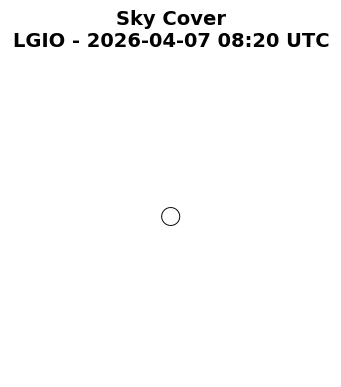

In [11]:
if len(df_lgio) > 0:
    # Create figure
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Create station plot at center
    stationplot = StationPlot(ax, [0], [0], fontsize=14, spacing=35)
    
    # cloud_cover = -1 means AUTO station with no cloud data -> skip symbol
    _cc = obs.get('cloud_cover', -1)
    sky_oktas = int(_cc) if _cc is not None and _cc == _cc and _cc >= 0 else -1
    if sky_oktas >= 0:
        stationplot.plot_symbol('C', [sky_oktas], sky_cover)
    
    ax.set_title(f"Sky Cover\n{obs['station']} - {obs['valid'].strftime('%Y-%m-%d %H:%M UTC')}",
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


### 3.2.3 Add Temperature (NW) and Dewpoint (SW)

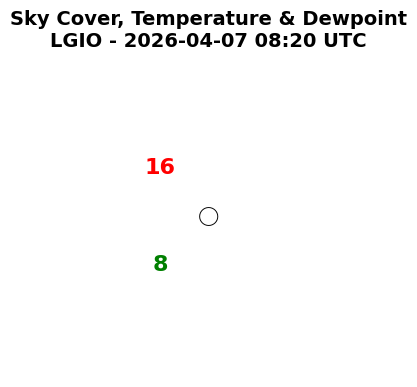

In [12]:
if len(df_lgio) > 0:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    stationplot = StationPlot(ax, [0], [0], fontsize=14, spacing=35)
    
    # Sky cover (skip for AUTO stations)
    if sky_oktas >= 0:
        stationplot.plot_symbol('C', [sky_oktas], sky_cover)
    
    # Add temperature and dewpoint
    stationplot.plot_parameter('NW', [round(obs['temp_c'])], color='red', fontsize=16, fontweight='bold')
    stationplot.plot_parameter('SW', [round(obs['dwpt_c'])], color='green', fontsize=16, fontweight='bold')
    
    ax.set_title(f"Sky Cover, Temperature & Dewpoint\n{obs['station']} - {obs['valid'].strftime('%Y-%m-%d %H:%M UTC')}",
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


### 3.2.4 Add Wind Barbs

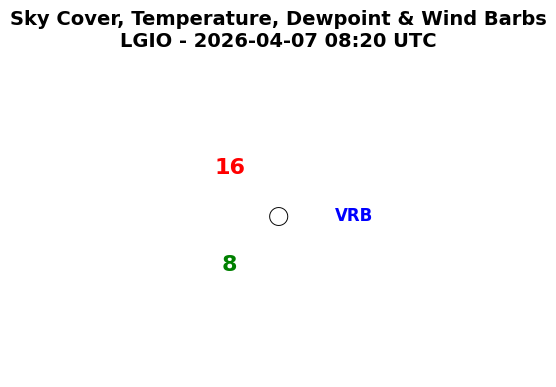

In [13]:
if len(df_lgio) > 0:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    stationplot = StationPlot(ax, [0], [0], fontsize=14, spacing=35)
    
    # Sky cover (skip for AUTO stations)
    if sky_oktas >= 0:
        stationplot.plot_symbol('C', [sky_oktas], sky_cover)
    
    # Temperature and dewpoint
    stationplot.plot_parameter('NW', [round(obs['temp_c'])], color='red', fontsize=16, fontweight='bold')
    stationplot.plot_parameter('SW', [round(obs['dwpt_c'])], color='green', fontsize=16, fontweight='bold')
    
    # Add wind barbs (skip if VRB = wdir is NaN)
    if pd.notna(obs['wdir']):
        u_wind = -obs['wspd'] * np.sin(np.radians(obs['wdir']))
        v_wind = -obs['wspd'] * np.cos(np.radians(obs['wdir']))
        stationplot.plot_barb([u_wind], [v_wind], length=8)
    else:
        ax.text(0.35, 0.0, 'VRB', fontsize=12, color='blue',
                ha='left', va='center', fontweight='bold')
    
    ax.set_title(f"Sky Cover, Temperature, Dewpoint & Wind Barbs\n{obs['station']} - {obs['valid'].strftime('%Y-%m-%d %H:%M UTC')}",
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


### 3.2.5 Add Mean Sea-Level Pressure (NE)

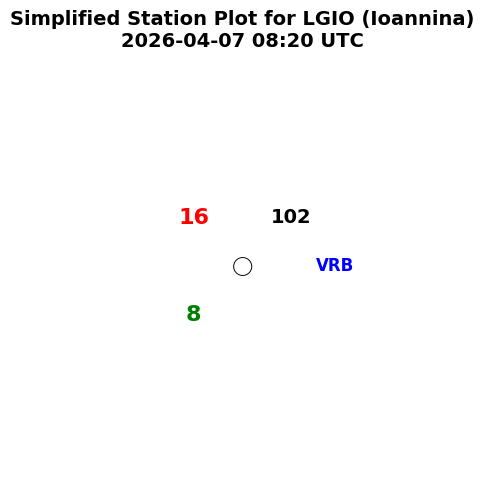

Figure saved to outputs/lgio_station_model.png


In [14]:
if len(df_lgio) > 0:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    stationplot = StationPlot(ax, [0], [0], fontsize=14, spacing=35)
    
    # Sky cover (skip for AUTO stations)
    if sky_oktas >= 0:
        stationplot.plot_symbol('C', [sky_oktas], sky_cover)
    
    # Temperature and dewpoint
    stationplot.plot_parameter('NW', [int(round(obs['temp_c']))], color='red', fontsize=16, fontweight='bold')
    stationplot.plot_parameter('SW', [int(round(obs['dwpt_c']))], color='green', fontsize=16, fontweight='bold')
    
    # Wind barbs (skip if VRB = wdir is NaN)
    if pd.notna(obs['wdir']):
        u_wind = -obs['wspd'] * np.sin(np.radians(obs['wdir']))
        v_wind = -obs['wspd'] * np.cos(np.radians(obs['wdir']))
        stationplot.plot_barb([u_wind], [v_wind], length=8)
    else:
        ax.text(0.35, 0.0, 'VRB', fontsize=12, color='blue',
                ha='left', va='center', fontweight='bold')
    
    # Add mean sea-level pressure (daPa)
    stationplot.plot_parameter('NE', [round(obs['mslp'] * 0.1, 1)], color='black', fontsize=14, fontweight='bold')
    
    ax.set_title(f"Simplified Station Plot for LGIO (Ioannina)\n{obs['valid'].strftime('%Y-%m-%d %H:%M UTC')}",
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    output_dir = Path('../outputs')
    output_dir.mkdir(exist_ok=True)
    plt.savefig(output_dir / 'lgio_station_model.png', dpi=150, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()
    
    print('Figure saved to outputs/lgio_station_model.png')


---

<div style="background-color: #d1e7dd; padding: 15px; border-radius: 8px; border-left: 4px solid #198754e0;">

## Checkpoint: What's the Weather in Ioannina?

Using the station plot constructed above, describe the prevailing weather conditions at LGIO (Ioannina) in plain, non-technical language, as you would communicate them to a non-specialist audience.


# Section 4: Synoptic Overview

## 4.1 Network-Scale Visualization

While the analysis of a single station plot provides valuable information about localized atmospheric conditions, examining the spatial distribution of surface observations from a broader network yields significantly greater diagnostic capabilities. Specifically, plotting multiple station plots together facilitates a synoptic overview of the prevailing weather conditions across the area of interest.

Therefore, in this section, we expand our analytical workflow from a single location (Ioannina) to encompass the **entire Greek METAR network**. The decoded and quality-controlled data we retrieved earlier are geolocated to accurately position each station plot on the map. To prevent the map from becoming visually overloaded, we plot a **simplified station plot** focusing exclusively on wind, temperature, and relative humidity.

> **Station coordinates** are retrieved from the [OurAirports open database](https://ourairports.com/data/).

Coordinate database: 59 Greek airport entries.
Stations matched to coordinates: 19


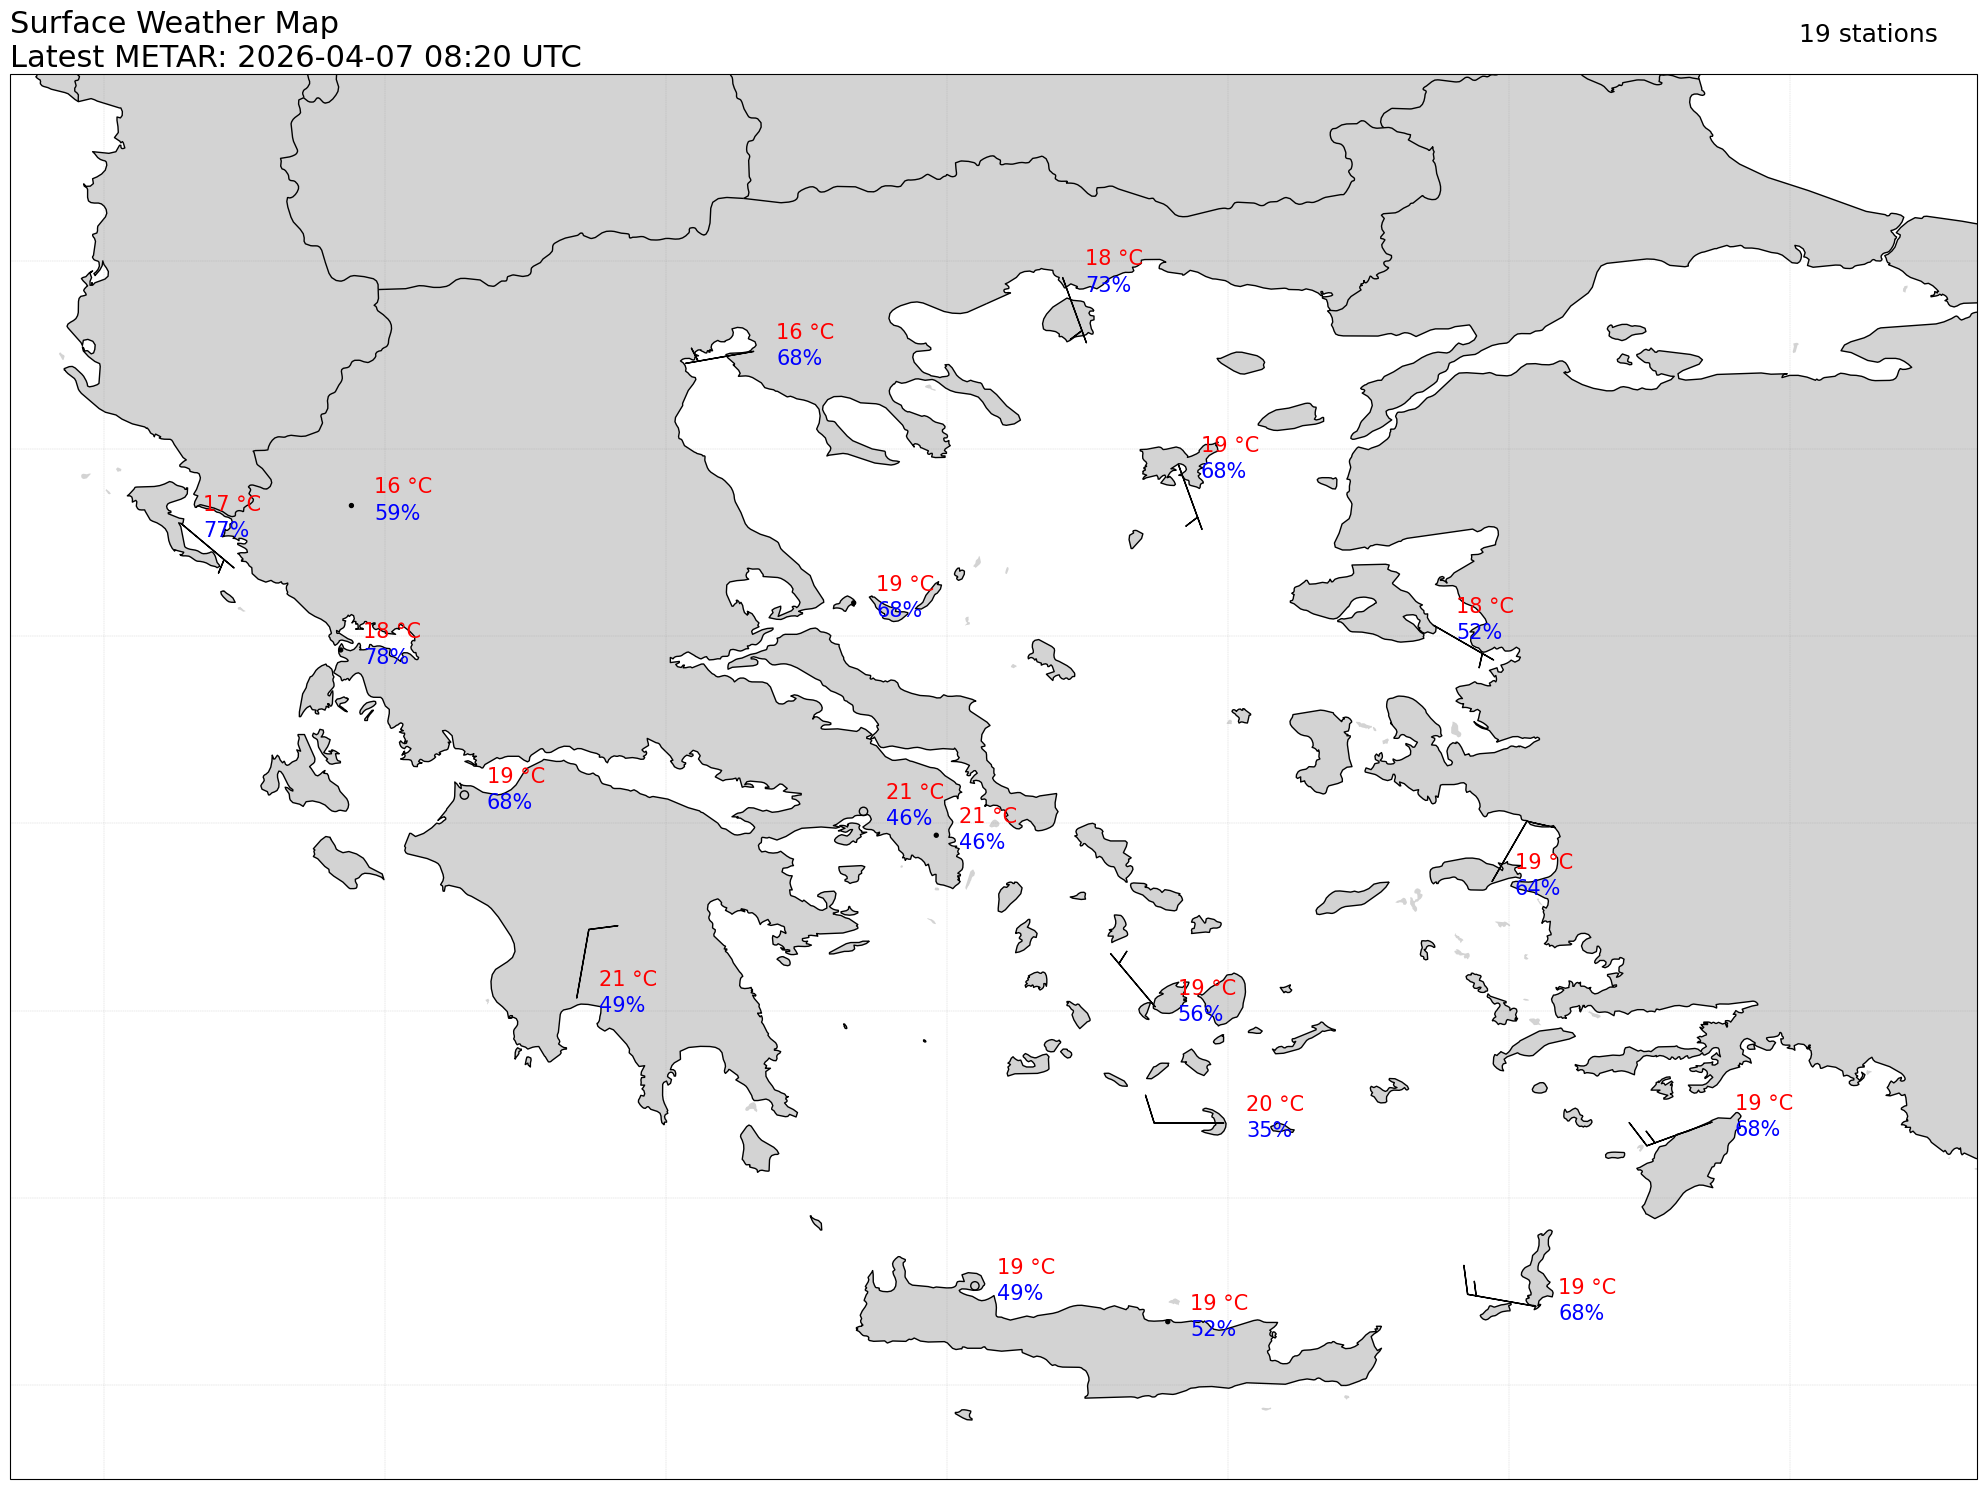

Figure saved to E:\Professorship (2026 -\01_Projects\07_Active_Teaching\2025-2026\Μ225 Weather Analysis and Forecasting\weather-analysis-and-forecasting\outputs\greece_metar_network_20260407_0849.png


In [15]:
# -------------------------------------------------------------------
# Step 1: Download station coordinates for the Greek (LG*) ICAO block
# -------------------------------------------------------------------
coords = fetch_station_coords()   # default: iso_country='GR'
print(f'Coordinate database: {len(coords)} Greek airport entries.')

# -------------------------------------------------------------------
# Step 2: Select one representative observation per station
#   Real-time mode      -> the single available NOAA snapshot
#   Retrospective mode  -> observation closest to 12:00 UTC
# -------------------------------------------------------------------
df_plot = build_network_plot_df(df_clean, coords)
print(f'Stations matched to coordinates: {len(df_plot)}')

if len(df_plot) == 0:
    print('[WARN] No stations matched. Verify that df_clean contains LG* '
          'ICAO codes and that the station list in Section 1 includes '
          'Greek airports.')

# -------------------------------------------------------------------
# Step 3: Draw the network map and save to outputs/
#   Each station shows:
#     Wind barbs  (black)   speed and direction in knots
#     VRB dot     (black)   variable-direction wind (size ~ speed)
#     Calm circle (black)   wind speed <= 1 kt
#     T label     (red)     temperature in degC
#     RH label    (blue)    relative humidity in %
# -------------------------------------------------------------------
if len(df_plot) > 0:
    out_path = plot_greece_metar_network(df_plot, output_dir='../outputs')
    print(f'Figure saved to {out_path}')


---

<div style="background-color: #fff3cd; padding: 15px; border-radius: 8px; border-left: 4px solid #ffc107;">

## Task 3: Basic Synoptic Pattern Recognition

**Goal**: Characterize the large-scale weather pattern over Greece from the spatial distribution of surface observations.

Use the network map to complete the following analyses:

1. **Thermal & Moisture Distribution:** Examine the spatial distribution of temperature and relative humidity. Can you identify regions with distinct temperature and moisture characteristics?
2. **Wind Field:** Examine the wind barbs for evidence of organized regional flow. Are there coherent directional patterns or areas of convergence?
3. **Synoptic Pattern:** Based on your analysis above, characterize the prevailing weather conditions across the network. 

---

<div style="background-color: #f8d7da; padding: 15px; border-radius: 8px; border-left: 4px solid #dc3545;">

## Pro Task: Extreme Event Case Studies

**Goal:** Apply synoptic pattern recognition to historically significant weather events in Greece.

Return to the Configuration cell (section 1.2), update `TARGET_DATE`, and re-run all cells. Apply the same analytical framework as in Task 3 to each of the following events:

1. **Medicane Ianos** (18 Sep 2020): A rare Mediterranean tropical-like cyclone (15–21 September 2020) that affected Greece, producing hurricane-force winds and extreme precipitation in Ionian Islands.

2. **Extreme Heat Wave** (03 Aug 2021): A prolonged extreme heat wave (July 28–August 05, 2021) that brought exceptionally hot and dry conditions across Greece, with maximum temperatures reaching 43.9 °C at Thissio, Athens.

Note that the same analytical framework can be applied to other high-impact events.

</div>

---

## 🏁 Summary & Key Takeaways

In this notebook, we completed a full **surface weather data analysis workflow**: from acquiring and decoding raw METAR observations to visualizing quality-controlled data on a map.

**Key Takeaways:**
* ✅ **METAR:** An international standard for reporting surface weather observations based on alphanumeric strings.
* ✅ **Data Acquisition:** Open archives provide free access to a global METAR record suitable for both real-time monitoring and retrospective analysis.
* ✅ **Unit Standardization:** Conversion to standard units is a necessary preprocessing step given the regional variability in METAR reporting conventions.
* ✅ **Quality Control:** Systematic QC checks are necessary before any scientific analysis is performed.
* ✅ **Visualization:** The station plot provides a compact, standardized encoding of surface conditions that scales from single-station inspection to network-wide synoptic overview.

> **Looking Ahead:** Extracting the full diagnostic value of a surface observation network requires contouring (isobars, isotherms, and related isopleths) to explicitly reveal pressure centers (Highs and Lows), frontal zones and other valuable information. These analysis techniques are introduced in the next notebook.

---

## References

1. Stull, R. (2017). *Practical Meteorology: An Algebra-based Survey of Atmospheric Science*. University of British Columbia. Available at: [https://www.eoas.ubc.ca/books/Practical_Meteorology](https://www.eoas.ubc.ca/books/Practical_Meteorology)

2. National Centers for Environmental Prediction (2026). *MADIS Meteorological Surface Quality Control Checks*. Available at: [https://madis.ncep.noaa.gov/madis_sfc_qc_notes.shtml](https://madis.ncep.noaa.gov/madis_sfc_qc_notes.shtml)


---

**🦉 Crafted with wisdom at One Weather Lab (OWL)**<br>
Laboratory of Meteorology and Climatology, Physics Department, University of Ioannina<br>
Christos Giannaros <<chris.giannaros@uoi.gr>>